# Estatística 1 - Aula prática 5_2 em Python

## UNIDADE 5: Testes nao Parametricos  

### Seção 5.2 Mann-Whitney "U" test

By Jose P. Leitão

In [22]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binom, mannwhitneyu

In [2]:
# Preparando os dados em dois vetores numericos pesos de homens e mulheres
women_weight = {"Woman": [38.9, 61.2, 73.3, 21.8, 63.4, 64.6, 48.4, 48.8, 48.5]}
men_weight = {"Man": [67.8, 60, 63.4, 76, 89.4, 73.3, 67.3, 61.3, 62.4]}

In [3]:
# Criando um data frame com o nome "weight"
weight = pd.DataFrame(list(women_weight.items()) + list(men_weight.items()),
                  columns=["group", "weight"])

weight = weight.explode("weight", ignore_index=True)

Queremos saber se o peso mediano das mulheres difere do peso mediano dos homens.

In [4]:
# Vamos primeiro calcular um sumario estatistico
resumo = (
    weight.groupby("group")
      .agg(
          contagem=("weight", "count"),
          mediana=("weight", "median"),
          IQR=("weight", lambda x: x.quantile(0.75) - x.quantile(0.25))
      )
      .reset_index()
)

print(resumo)

   group  contagem mediana   IQR
0    Man         9    67.3  10.9
1  Woman         9    48.8  15.0


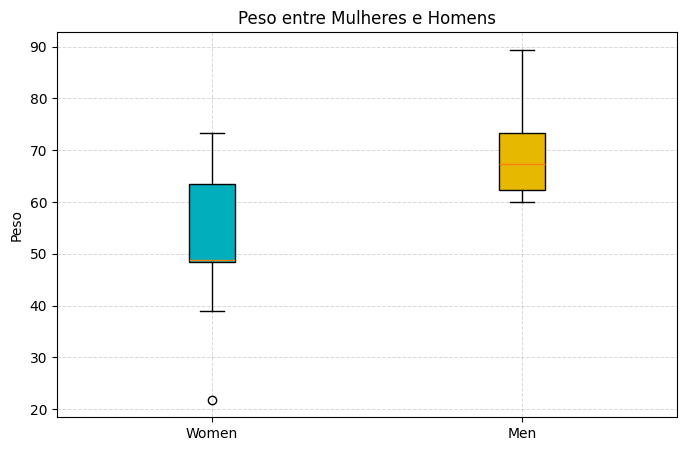

In [20]:
# Vamos visualizar os dados usando box-plots

labels = ['Women', 'Men' ]
colors = ["#00AFBB","#E7B800" ]

fig, ax = plt.subplots(figsize=(8,5))
ax.set_ylabel('Peso')
ax.set_title("Peso entre Mulheres e Homens")

bplot = ax.boxplot([women_weight["Woman"], men_weight["Man"]],
                   patch_artist=True,  # fill with color
                   tick_labels=labels, # will be used to label x-ticks
                   ) 
 
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    
# Cor de fundo do gráfico (área interna)
ax.set_facecolor("white")

# Cor do fundo externo (figura inteira)
fig.patch.set_facecolor("white")

# Grade
ax.grid(True, color="gray", linestyle="--", linewidth=0.7, alpha=0.3)

plt.show()

In [21]:
# Vamos fazer o teste se o peso mediano dos homens eh igual ao
# peso mediano das mulheres

# Hipoteses do teste:

# H0: O peso mediano dos homens eh igual estatisticamente ao peso
#     mediano das mulheres;
# Ha: O peso mediano dos homens nao eh estatisticamente igual ao
#     peso mediano das mulheres

In [27]:
# O teste eh sempre feito com relacao a disposicao no vetor de
# dados, do ultimo para o primeiro - No vetor: Man contra Woman
x1 = np.array(women_weight["Woman"])
x2 = np.array(men_weight["Man"])

u_stat, p = mannwhitneyu(x1, x2, alternative="two-sided")

print("U =", u_stat)
print(f"p-value = {p:.5f}")

U = 15.0
p-value = 0.02712


In [ ]:
# O p-value do teste eh 0,02712, que eh menor que o nivel de
# significancia 0,05. Podemos concluir que o peso mediano dos
# homens eh estatisticamente diferente do peso mediano das
# mulheres (rejeitamos H0).
# #####O intervalo de confianca da diferenca entre as medianas esta 
# #####entre 1,20 e 28.20, com uma mediana de 14,60.

In [31]:

B = 10000
diffs = []

for _ in range(B):
    xs = np.random.choice(x1, size=len(x1), replace=True)
    ys = np.random.choice(x2, size=len(x2), replace=True)
    diffs.append(np.median(ys) - np.median(xs))

ci = np.percentile(diffs, [2.5, 97.5])

print("IC 95%:", ci)

IC 95%: [-1.  27.6]


In [ ]:
# Se quisermos testar se o peso mediano dos homens eh menor
# que o peso mediano das mulheres:

# Hipoteses do teste:

# H0: O peso mediano dos homens nao eh estatisticamente menor que
#     o peso mediano das mulheres;
# Ha: O peso mediano dos homens eh estatisticamente menor que o 
#     peso mediano das mulheres.

# Ha: x2<x1

u_stat, p = mannwhitneyu(x2, x1, alternative="less")

print("U =", u_stat)
print(f"p-value = {p:.5f}")


U = 66.0
p-value = 0.98923


In [ ]:
# Como p-value > 0.05, aceitamos H0, o peso mediano dos homens 
# nao eh menor que o peso mediano das mulheres
# O intervalo de confianca da diferenca entre as medianas eh um
# valor menor que 26,00, com uma mediana de 14,60

In [ ]:
# Se quisermos testar se o peso mediano dos homens eh maior que
# o peso mediano das mulheres:

# Hipoteses do teste:

# H0: O peso mediano dos homens nao eh estatisticamente maior que
#     o peso mediano das mulheres;
# Ha: O peso mediano dos homens eh estatisticamente maior que o 
#     peso mediano das mulheres.

# Ha: x2>x1

u_stat, p = mannwhitneyu(x2, x1, alternative="greater")

print("U =", u_stat)
print(f"p-value = {p:.5f}")

U = 66.0
p-value = 0.01356


In [ ]:
# Como p-value < 0.05, o peso mediano dos homens eh 
# estatisticamente maior que o peso mediano das mulheres 
# (rejeitamos H0).
# O intervalo de confianca para a diferenca entre as medianas eh 
# um valor maior que 3,19 com uma mediana de 14,60